# **03. Predicting High-Value Buyer using ML Models &  Pareto Analysis**


### **Introduction**

Our study will use __RFM features__ to identify __high-value customers__ using ML models and perform __Pareto analysis__. The aim is to show how a small group of customers generates most of the revenue, helping businesses focus their marketing and resources more effectively.

### **Goal**
__1. The goal is to predict whether a customer qualifies as a High-Value Customer__ 

To define this target, we'll label the top 25% of customers by total spending as 1 (High Value) and the remaining 75% as 0. For predictors, we'll focus on two behavioral features: Recency and Frequency.

__2. Apply Pareto Analysis__



## **1. Requirements**

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable
from pathlib import Path
from IPython.display import display
from IPython.display import Markdown



In [2]:
# display setting
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

import warnings
warnings.simplefilter("ignore", category=FutureWarning)

# Display markdown formatted output like bold, italic bold etc.'''
def display_md(string):
    display(Markdown(string))

 

In [3]:
   

# Define paths to read files
parent_path = Path.cwd().parent
data_path = parent_path.joinpath('data', 'processed')

files = []
for file in data_path.rglob('*.csv'):
    files.append(file)
    print(files.index(file), ' ', file.name)



0   kmeans_df.csv
1   processed_data.csv


In [4]:

display_md("**Loading Preprocessed and KMeans Dataset...**")
try:
    processed_df = pd.read_csv(files[1])
    kmeans_df = pd.read_csv(files[0])
    
    # standardize the column names
    processed_df.columns = processed_df.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")
    kmeans_df.columns = kmeans_df.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")
    
    # take a copy of original dataframe
    customer_df = processed_df.copy()
    
    # Conversion of 'Dt_Customer' into datetime
    customer_df['Dt_Customer'] = pd.to_datetime(customer_df['Dt_Customer'], format='%Y-%m-%d')#, dayfirst=True)
    display_md(f"**Dataset Shape : {customer_df.shape}**")
    display_md(f"**Number of duplicate rows in dataset : {customer_df.duplicated().sum()}**")
    
except Exception as e:
    print(f"Error raised while loading file : {e}")



**Loading Preprocessed and KMeans Dataset...**

**Dataset Shape : (2214, 39)**

**Number of duplicate rows in dataset : 0**

## **2. High-Value Customer Prediction**

In [5]:
# Will use kmeans_df for predict high-value customers and do pareto analysis
cluster_df = kmeans_df.copy()

**2.1. Train-Test Split**

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Define target feature : Top 25% of customers by Monetary values are "High Value"
# consider `cluster_df` dataset for this
threshold = cluster_df['Monetary'].quantile(0.75)
cluster_df['Is_High_Value'] = (cluster_df['Monetary'] > threshold).astype(int)

# Define independent features and target feature
X = cluster_df[['Recency', 'Frequency']]    # Predicting based on behavior
y = cluster_df['Is_High_Value']

# Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features for algorithms that are sensitive to scale (like Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data size: {X_train.shape[0]}")
print(f"Testing data size: {X_test.shape[0]}")




Training data size: 1771
Testing data size: 443


**2.2. Model Training**

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Train multiple models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Dictionary to store predictions
predictions = {}

for name, model in models.items():
    # Fit model (using scaled data for LR, and unscaled for Tree-based models)
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        
    predictions[name] = preds
    print(f"{name} trained successfully.")





Logistic Regression trained successfully.
Random Forest trained successfully.
XGBoost trained successfully.


c:\Users\Admin\anaconda3\envs\test_titanic\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:21:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


**2.3. Model Evaluation**


Model: Logistic Regression
Accuracy: 0.7991

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       332
           1       0.61      0.53      0.57       111

    accuracy                           0.80       443
   macro avg       0.73      0.71      0.72       443
weighted avg       0.79      0.80      0.79       443



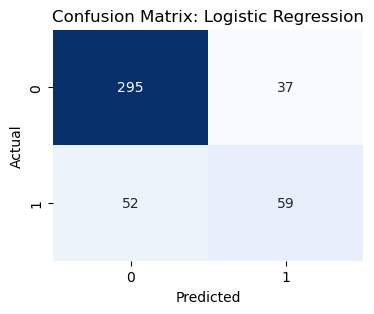


Model: Random Forest
Accuracy: 0.8036

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.89      0.87       332
           1       0.62      0.55      0.58       111

    accuracy                           0.80       443
   macro avg       0.74      0.72      0.73       443
weighted avg       0.80      0.80      0.80       443



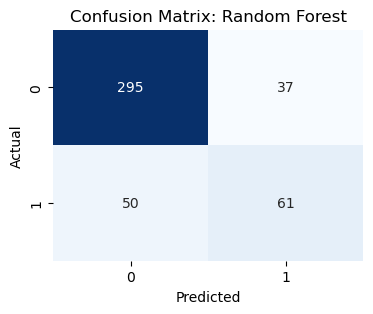


Model: XGBoost
Accuracy: 0.7991

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.87      0.87       332
           1       0.60      0.58      0.59       111

    accuracy                           0.80       443
   macro avg       0.73      0.73      0.73       443
weighted avg       0.80      0.80      0.80       443



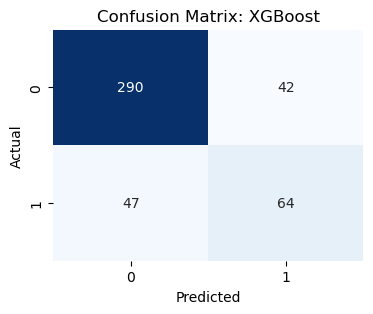

In [8]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

#  Evaluate Models
for name, preds in predictions.items():
    print(f"\n{'='*30}")
    print(f"Model: {name}")
    print(f"{'='*30}")
    
    accuracy = accuracy_score(y_test, preds)
    print(f"Accuracy: {accuracy:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, preds))
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()



**2.4. RFM Distribution**

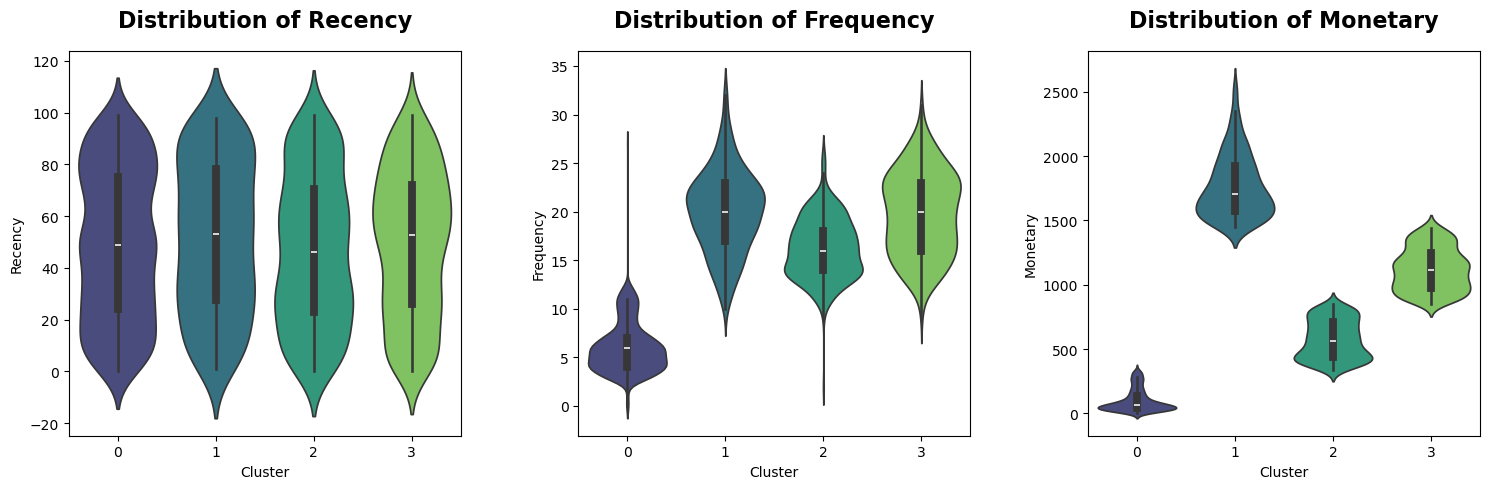

In [9]:

# Violin Plots to see data distribution and density per cluster
features_to_plot = ['Recency', 'Frequency', 'Monetary']

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
#ax= ax.flatten()

for i, col in enumerate(features_to_plot):
    # Violin plots show the median, range, and where the bulk of the data lies
    sns.violinplot(x='Cluster', y=col, data=cluster_df, palette='viridis', ax=ax[i])
    ax[i].set_title(f'Distribution of {col}', fontsize=16, fontweight='bold', y=1.04)
    
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()



**2.5. Feature Importance Analysis**

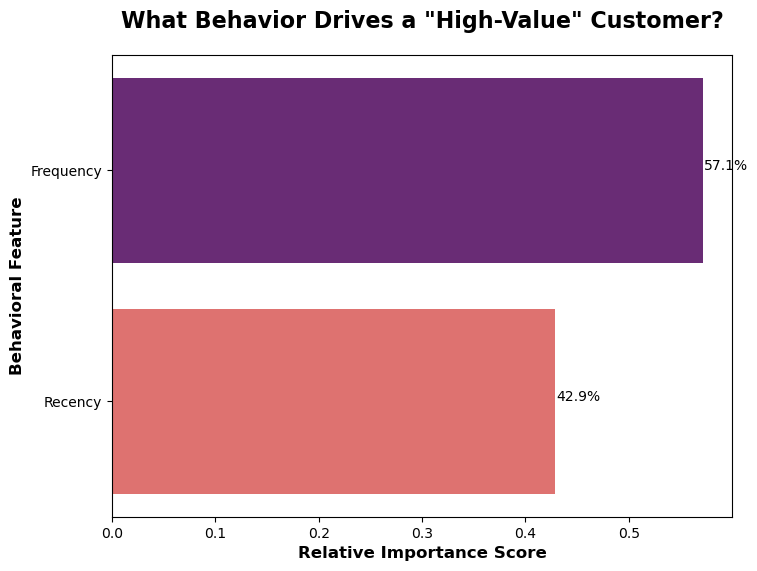

In [10]:
#  Feature Importance Analysis
# Retrieve the Random Forest model we trained
rf_model = models["Random Forest"]

# Extract importance scores
importances = rf_model.feature_importances_
feature_names = X.columns # ['Recency', 'Frequency']

# Create a DataFrame for easy plotting
importance_df = pd.DataFrame({
    'Feature': feature_names, 
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')
plt.title('What Behavior Drives a "High-Value" Customer?', fontsize=16, fontweight='bold', y=1.04)
plt.xlabel('Relative Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Behavioral Feature', fontsize=12, fontweight='bold')

# Add percentage text to bars
for idx, row in importance_df.iterrows():
    plt.text(row['Importance']+0.001, row['Feature'], f"{row['Importance']*100:.1f}%")

plt.show()


## **3. Pareto Analysis**

Pareto analysis is a technique based on the 80/20 rule, which suggests that about 20% of causes often lead to 80% of results. In a customer context, it means a small group of high-value customers usually generates most of the revenue. By applying this method, businesses can quickly identify which customers are most impactful and focus their efforts on retaining and engaging them.

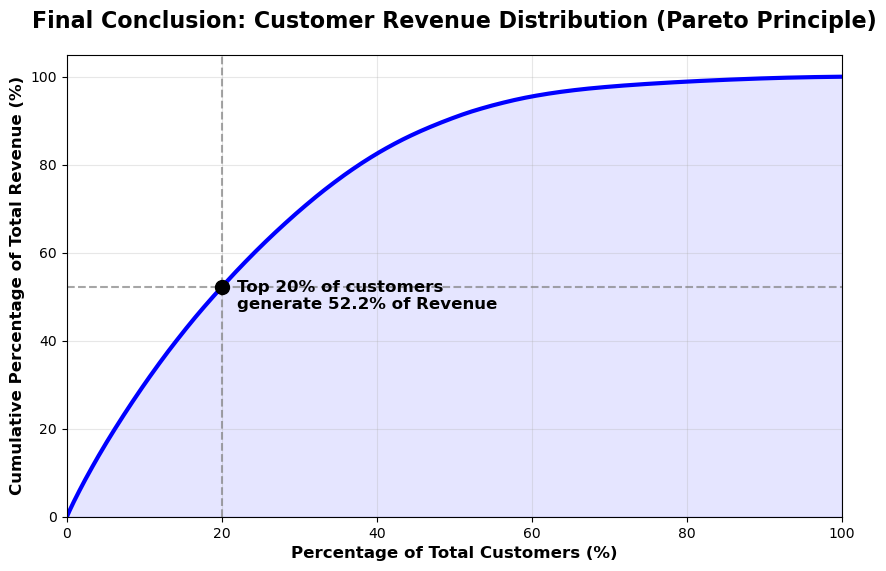

In [11]:
# Business Conclusion - The Pareto Analysis
# Sort customers by Monetary value descending
pareto_df = cluster_df.sort_values(by='Monetary', ascending=False).reset_index(drop=True)

# Calculate cumulative percentage of customers and cumulative percentage of revenue
pareto_df['Cumulative_Revenue'] = pareto_df['Monetary'].cumsum()
pareto_df['Cumulative_Revenue_Pct'] = pareto_df['Cumulative_Revenue'] / pareto_df['Monetary'].sum() * 100
pareto_df['Customer_Pct'] = (pareto_df.index + 1) / len(pareto_df) * 100

# Find the point where top 20% of customers are
top_20_revenue = pareto_df[pareto_df['Customer_Pct'] <= 20]['Cumulative_Revenue_Pct'].max()

# Plotting the Executive Pareto Chart
plt.figure(figsize=(10, 6))
plt.plot(pareto_df['Customer_Pct'], pareto_df['Cumulative_Revenue_Pct'], 
         color='blue', linewidth=3, label='Cumulative Revenue %')

# Add reference lines for the 80/20 rule
plt.axvline(x=20, color='grey', linestyle='--', alpha=0.7)
plt.axhline(y=top_20_revenue, color='grey', linestyle='--', alpha=0.7)
plt.scatter(20, top_20_revenue, color='black', s=100, zorder=5)

# Annotations
plt.text(22, top_20_revenue - 5, f'Top 20% of customers\ngenerate {top_20_revenue:.1f}% of Revenue', 
         fontsize=12, fontweight='bold', color='black')

plt.title('Final Conclusion: Customer Revenue Distribution (Pareto Principle)', fontsize=16, fontweight='bold', y=1.04)
plt.xlabel('Percentage of Total Customers (%)', fontsize=12, fontweight='bold')
plt.ylabel('Cumulative Percentage of Total Revenue (%)', fontsize=12, fontweight='bold')
plt.fill_between(pareto_df['Customer_Pct'], pareto_df['Cumulative_Revenue_Pct'], color='blue', alpha=0.1)
plt.xlim(0, 100)
plt.ylim(0, 105)
plt.grid(alpha=0.3)
plt.show()

### **Conclusion & Strategic Growth Recommendations**

Based on the Machine Learning Model (Random Forest classification) applied to customer transaction data, we have identified clear insights that can guide future business growth.

#### **Key Findings :**

**1. Frequency Over Recency :** Our Random Forest features importance proved that how often a customer buys(Frequency) is a strong predictor of high-value customer than how recently they bought. This finding indicates that encouraging repeat purchases is more critical for long-term profitability than focusing solely on recent customer activity.

**2. Pareto Analysis :** As shown in the final plot, a small fraction of our customer base — the top 20% — is responsible for 52.2% of total revenue. While this is lower than the classic 80/20 benchmark, it still highlights that a minority of high-value customers drive a significant/majority share of business performance. High-value customers illustrated significantly higher purchase frequency and spending levels compared to the rest of the customer base.

By combining customer segmentation, Pareto analysis, and machine learning-based prediction, the business can proactively identify high-value customers, allocate resources more effectively, and implement targeted retention strategies. Prioritizing these customers through personalized marketing, loyalty programs, and enhanced customer experiences can significantly increase customer lifetime value, improve retention rates, and drive significant business growth.


### **Future Work:** 

The saved segmentation file will be used in the next stage to implement a probabilistic approach for computing Customer Lifetime Value (CLTV). The BG/NBD model will estimate how long customers remain active and how many future purchases they are likely to make, while the Gamma-Gamma model will predict the average profit expected from each customer. Together, these models provide a comprehensive view of customer profitability and long-term business value.